In [1]:
# import packages
import numpy as np
import matplotlib.pyplot as plt

# 1.
## a)

Text(0.5, 1.0, 'Plot of f(x) to investigate roots')

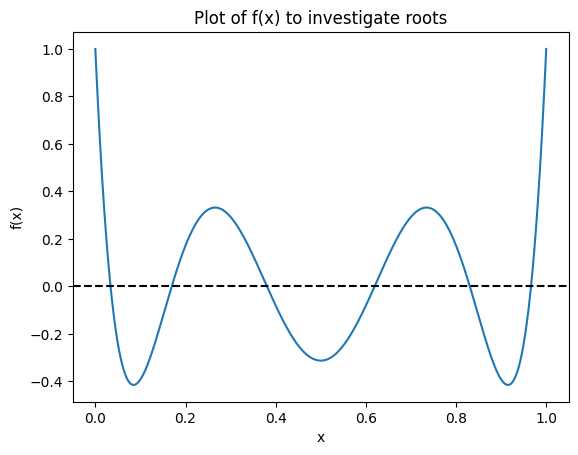

In [2]:
def f1a(x):
    return 924*x**6 - 2772*x**5 + 3150*x**4 - 1680*x**3 + 420*x**2 - 42*x + 1

x = np.linspace(0, 1, 1001)
y = f1a(x)

plt.plot(x, y)
plt.axhline(y=0, ls="--", c="k")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Plot of f(x) to investigate roots")

My guesses for the roots are 0.01, 0.18, 0.4, 0.6, 0.85, and 0.95.

## b)

In [3]:
# define the derivative analytically
def fprime(x):
    return 5544*x**5 - 13860*x**4 + 12600*x**3 - 5040*x**2 + 840*x - 42

# define a function for Newton's Method
def Newton(f, fprime, initial, k_max=100, tol=1e-10):
    x_old = initial
    for i in range(k_max):
        x_new = x_old - (f(x_old)/fprime(x_old))

        if abs(x_new - x_old) <= tol:
            break

        x_old = x_new

    return x_new

# iterate through my guesses 
guesses = [0.01, 0.18, 0.4, 0.6, 0.85, 0.95]
x_stars = []

for guess in guesses:
    x_star = Newton(f1a, fprime, guess)
    x_stars.append(x_star)

print("The zeroes are: ", x_stars)

The zeroes are:  [0.03376524289842399, 0.1693953067668678, 0.3806904069584, 0.619309593041593, 0.8306046932331075, 0.966234757101586]


## c)

The answers can be verified by inputting them into the original function.

In [4]:
for x_star in x_stars:
    print(f"f({x_star}) = {f1a(x_star)}")

f(0.03376524289842399) = -2.220446049250313e-16
f(0.1693953067668678) = -8.881784197001252e-16
f(0.3806904069584) = 2.3092638912203256e-14
f(0.619309593041593) = -6.394884621840902e-14
f(0.8306046932331075) = 2.8421709430404007e-13
f(0.966234757101586) = 3.055333763768431e-13


Text(0, 0.5, 'f(x)')

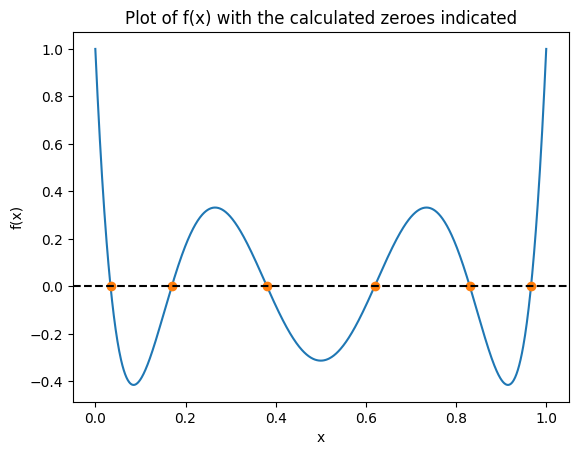

In [5]:
plt.plot(x, f1a(x))
plt.plot(x_stars, np.zeros(len(x_stars)),'o')
plt.axhline(y=0, ls='--', c='k')
plt.title("Plot of f(x) with the calculated zeroes indicated")
plt.xlabel("x")
plt.ylabel('f(x)')

# 2.
## a) 
First thing I'll do is plot the function to get an idea where the zero is at

Text(0.5, 1.0, 'Plot of f(x)')

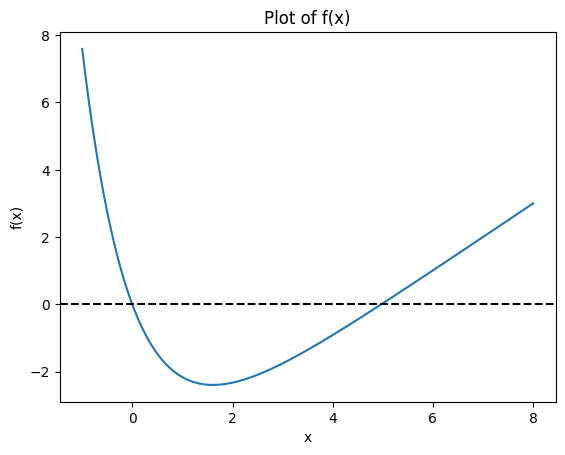

In [6]:
# define the function
def f2(x):
    return 5*np.exp(-x) + x - 5

# plot the funtion to get a guess as to where the other 0 is
x = np.linspace(-1, 8, 1001)
plt.plot(x,f2(x))
plt.axhline(y=0, ls='--', c='k')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Plot of f(x)')

The other zero seems to be around 5.

To use the relaxation method, we have to define $g(x)$. Since $f(x) = 5e^{-x} + x - 5 = 0$, we can rearrange this so that $x=5-5e^{-x}$ meaning $g(x) = 5-5e^{-x}$. In order for the relaxation method to converge, $|g'(x)| < 1$. In our case, $g'(x) = 5e^{-x}$ which is $<1$ for $x>ln(5)$ so this method should converge.

In [7]:
# define g(x)
def g(x):
    return 5 - 5*np.exp(-x)
    

In [8]:
# define the relaxation method
def relaxation(g, x0, kmax=100, tol=1.0e-10):
    xold = x0
    for k in range(1,kmax+1):
        xnew = g(xold)
            
        if abs(xnew - xold) < tol: break
            
        xold = xnew
                
    #The following 4 lines can be commented out.
    if(k == kmax):
        print('max iteration reached.')
    else:
        print(k, 'iterations to reach accuracy.')

    return xnew

x_star = relaxation(g, 5) # using x=5 as my initial guess
print(x_star)

7 iterations to reach accuracy.
4.965114231746431


## b)
Now that we know the value of the root, we can solve for the temperature from the equation
\begin{equation}
    x^* = \frac{hc}{\lambda k_B T}
\end{equation}
which gives us the expression for $T$
\begin{equation}
    T = \frac{hc}{\lambda k_B x^*}
\end{equation}

In [9]:
# define constants
hc = 1240 # eV nm
lambd_a = 502 # nm
k_B = 8.617e-5 # eV / K

temp = hc / (lambd_a * k_B * x_star)
print(f"The temperature of the sun's surface is around {temp} K")

The temperature of the sun's surface is around 5773.413060950302 K


# 3.
## a)

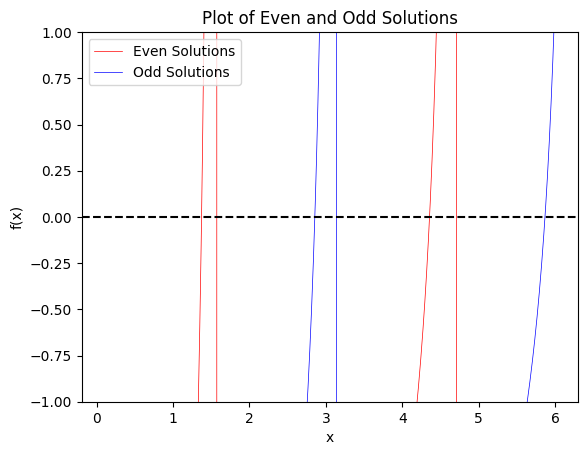

In [10]:
# define the even and odd solutions
def EvenSols(z):
    return np.tan(z) - np.sqrt((36/z) - 1)

def OddSols(z):
    return -1*(1/np.tan(z)) - np.sqrt((36/z) - 1)

# plot the functions to get an idea as to where the zeroes are
x = np.linspace(0.1, 6, 1001)
plt.plot(x, EvenSols(x), c=(1,0,0), lw=0.5, label='Even Solutions')
plt.plot(x, OddSols(x), c=(0,0,1), lw=0.5, label='Odd Solutions')
plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Plot of Even and Odd Solutions')
plt.ylim(-1, 1)
plt.axhline(y=0, ls='--', c='k')

In [11]:
# define the bisection method
def Bisection(f, x0, x1, kmax = 100):

    f0=f(x0)
    f1=f(x1)
        
    if (f0*f1>0):
        print('f0*f1 should be less than 0.')
        return None
    
    if (f0*f1==0):
        print('The initial x0 or x1 is the solution.')
        return None

    for k in range(1,kmax+1):

        x2=(x0+x1)/2

        f0=f(x0); f1=f(x1); f2=f(x2)
        
        if (f0*f2) < 0:
            x1 = x2
        else:
            x0 = x2

        if (f0*f2 == 0):
            k_last = k
            break
    return x2

even_sol_1 = Bisection(EvenSols, 1, 1.5)
even_sol_2 = Bisection(EvenSols, 4, 4.5)
odd_sol_1 = Bisection(OddSols, 2.5, 3)
odd_sol_2 = Bisection(OddSols, 5.5, 6)
print(f'The even solutions are {even_sol_1} and {even_sol_2}.')
print(f'The odd solutions are {odd_sol_1} and {odd_sol_2}.')

The even solutions are 1.3741574375326782 and 4.357066087502616.
The odd solutions are 2.8560638503681766 and 5.867607017287549.


# b)

Text(0, 0.5, 'f(x)')

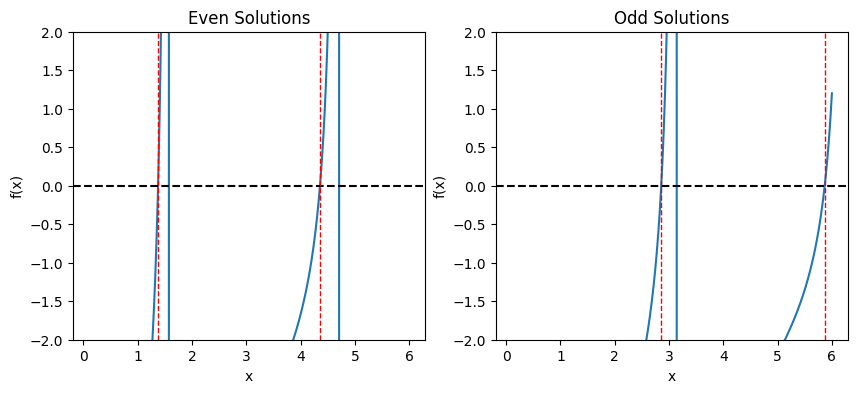

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].plot(x, EvenSols(x))
axes[0].set_ylim(-2, 2)
axes[0].axhline(y=0, ls='--', c='k')
axes[0].axvline(x=even_sol_1, ls='--', c='r', lw=1)
axes[0].axvline(x=even_sol_2, ls='--', c='r', lw=1)
axes[0].set_title('Even Solutions')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')

axes[1].plot(x, OddSols(x))
axes[1].set_ylim(-2, 2)
axes[1].axhline(y=0, ls='--', c='k')
axes[1].axvline(x=odd_sol_1, ls='--', c='r', lw=1)
axes[1].axvline(x=odd_sol_2, ls='--', c='r', lw=1)
axes[1].set_title('Odd Solutions')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')

# 4.

To solve this, we'll move the $\omega^2 r$ term to the left and find zeroes of the equation
\begin{equation}
    \frac{GM}{r^2} - \frac{Gm}{(R-r)^2} - \omega^2 r = 0
\end{equation}

Text(0, 0.5, 'Force (N)')

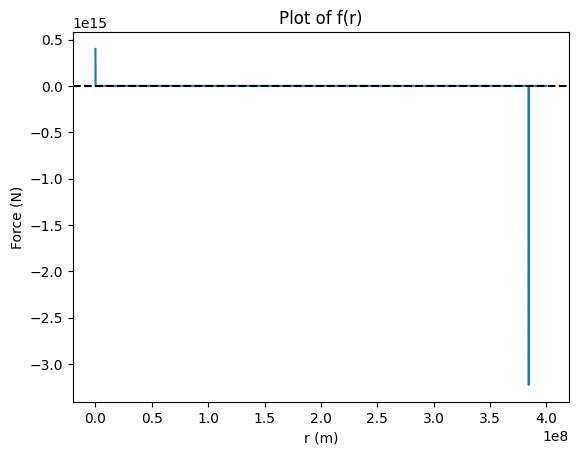

In [13]:
# define all of the constants to be used
G = 6.674e-11 # m^3 / kg s^2
M_earth = 5.974e24 # kg
m_moon = 7.348e22 # kg
R = 3.844e8 # m
omega = 2.662e-6 # 1/s

def function(r):
    return (G * M_earth / r**2) - (G * m_moon / (R - r)**2) - omega**2 * r

r = np.linspace(1, 4e8, 10001)
plt.plot(r, function(r))
# plt.yscale('log')
plt.axhline(y=0, ls='--', c='k')
plt.title('Plot of f(r)')
plt.xlabel('r (m)')
plt.ylabel('Force (N)')

It's hard to tell, but the zero should be between 3.5e8 and 4e8 m.

In [14]:
def Secant(f, x0, x1, kmax= 100, tol=1.0e-10):
    
    for k in range(1,kmax+1):
        f0 = f(x0)
        f1 = f(x1)
        ratio = (x1-x0)/(f1-f0)
        x2 = x1 - f1*ratio

        xdiff = abs(x2-x1)
        
        if(xdiff <= tol):
            break
        
        x0 = x1
        x1 = x2
        
    #The following 4 lines can be commented out.
    if(k == kmax):
        print('max iteration reached.')
    else:
        print(k, 'iterations to reach accuracy.')    
        
    return x2

lagrange_point = Secant(function, 3.5e8, 3.6e8, tol=1e-16)
print(f'The lagrange point is {lagrange_point/1000} km away from earth')

10 iterations to reach accuracy.
The lagrange point is 326045.07166535547 km away from earth
